# Análisis exploratorio de incidencia delictiva en México

Se usa `data/datos_delitos.csv` para conservar los subtipos **Homicidio doloso** y **Robo de vehículo automotor**, que se perdieron al agrupar `delitos.csv`. Se suman las modalidades dentro de cada subtipo.

Los datos son estatales: no permiten identificar municipios. Los meses sin información se conservan como faltantes, no como ceros. **2024 solo contiene enero a junio**, por lo que sus totales son parciales.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Cargar el archivo original y conservar el detalle necesario para los ejercicios.
original = pd.read_csv('data/datos_delitos.csv', encoding='ISO-8859-1')
original = original.rename(columns={
    'Año': 'anio', 'Clave_Ent': 'clave_ent', 'Entidad': 'entidad',
    'Tipo de delito': 'tipo_de_delito', 'Subtipo de delito': 'subtipo_de_delito',
    'Modalidad': 'modalidad'
})
meses = ['Enero', 'Febrero', 'Marzo', 'Abril', 'Mayo', 'Junio',
         'Julio', 'Agosto', 'Septiembre', 'Octubre', 'Noviembre', 'Diciembre']
detalle = original.melt(
    id_vars=['anio', 'clave_ent', 'entidad', 'tipo_de_delito', 'subtipo_de_delito', 'modalidad'],
    value_vars=meses, var_name='nombre_mes', value_name='frecuencia'
)
detalle['mes'] = detalle['nombre_mes'].map({mes: i + 1 for i, mes in enumerate(meses)})
detalle['fecha'] = pd.to_datetime(dict(year=detalle['anio'], month=detalle['mes'], day=1))
detalle['nombre_mes'] = detalle['nombre_mes'].str.lower()
print('Valores mensuales sin información:', detalle['frecuencia'].isna().sum())
# Excluir observaciones no reportadas; no convertirlas en delitos de frecuencia cero.
detalle = detalle.dropna(subset=['frecuencia']).copy()
claves = ['anio', 'clave_ent', 'entidad', 'tipo_de_delito', 'nombre_mes', 'fecha']
df = detalle.groupby(claves, as_index=False)['frecuencia'].sum(min_count=1)
print('Periodo con datos:', df['fecha'].min().date(), 'a', df['fecha'].max().date())
display(df.head())

Valores mensuales sin información: 18816
Periodo con datos: 2015-01-01 a 2024-06-01


,anio,clave_ent,entidad,tipo_de_delito,nombre_mes,fecha,frecuencia
0,2015,1,Aguascalientes,Aborto,abril,2015-04-01,0.0
1,2015,1,Aguascalientes,Aborto,agosto,2015-08-01,0.0
2,2015,1,Aguascalientes,Aborto,diciembre,2015-12-01,0.0
3,2015,1,Aguascalientes,Aborto,enero,2015-01-01,0.0
4,2015,1,Aguascalientes,Aborto,febrero,2015-02-01,3.0


#### Ejercicio 1: Elige 3 estados de la república y grafica una serie de tiempo de la frecuencia abosluta de homicidios dolosos de enero 2015 a julio 2019 en estas tres entidades

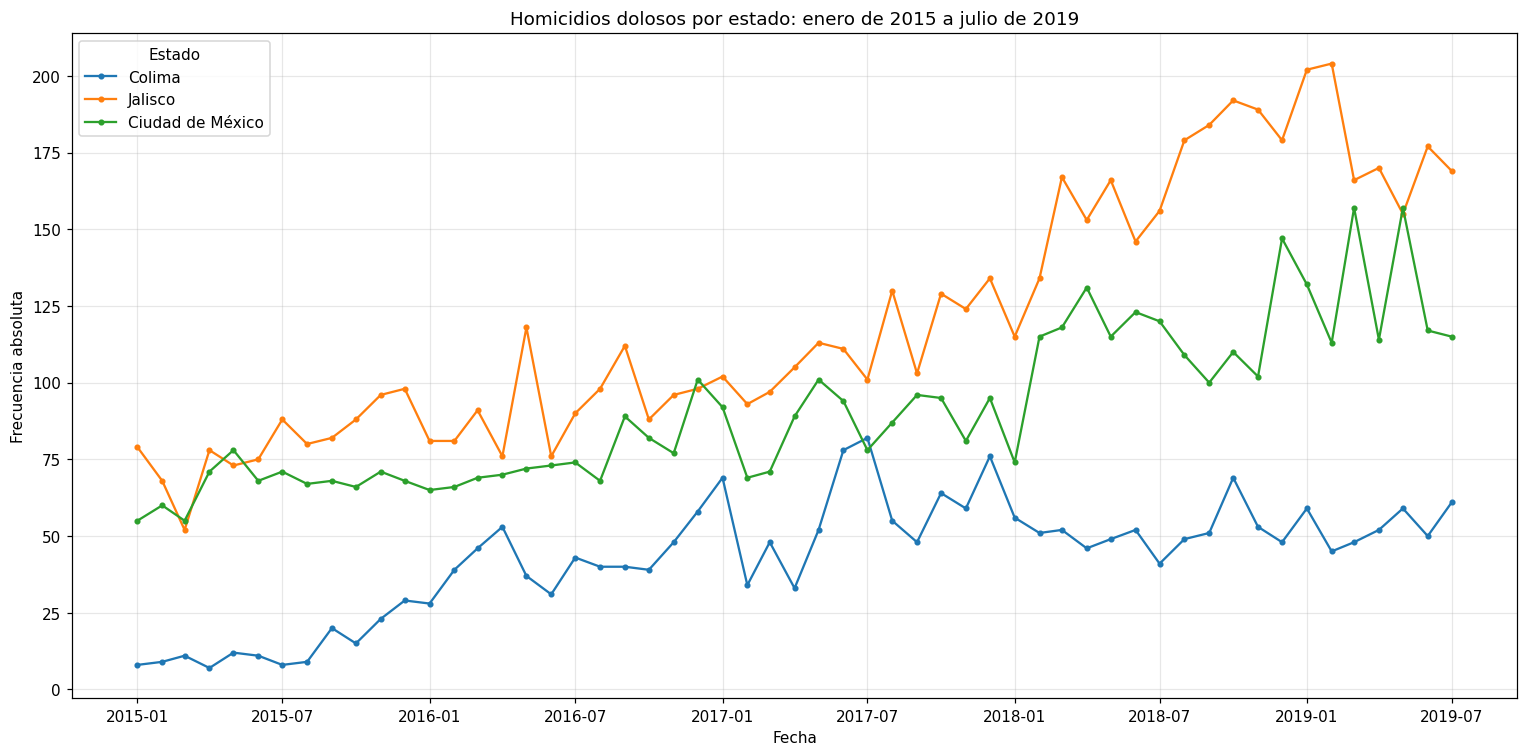

In [3]:
# Ejercicio 1: homicidios DOLOSOS, conservando el subtipo original.
estados_elegidos = ['Colima', 'Jalisco', 'Ciudad de México']
seleccion = detalle[
    detalle['subtipo_de_delito'].eq('Homicidio doloso') &
    detalle['entidad'].isin(estados_elegidos) &
    detalle['fecha'].between('2015-01-01', '2019-07-31')
]
serie = seleccion.groupby(['entidad', 'fecha'], as_index=False)['frecuencia'].sum(min_count=1)
plt.figure(figsize=(14, 7))
for estado in estados_elegidos:
    datos_estado = serie[serie['entidad'].eq(estado)].sort_values('fecha')
    plt.plot(datos_estado['fecha'], datos_estado['frecuencia'], label=estado, marker='o', markersize=3)
plt.title('Homicidios dolosos por estado: enero de 2015 a julio de 2019')
plt.xlabel('Fecha')
plt.ylabel('Frecuencia absoluta')
plt.legend(title='Estado')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### Ejercicio 2: Contetas las siguientes  preguntas:
1. ¿Cuántos homicidios dolosos hubo en Colima en el 2018?
2. ¿Cuantos robos de vehículo automotor ha habido en el 2019?
3. Obten la suma de homicidos dolosos y feminidios en toda la República Mexicana en cada año.
4. ¿En qué mes y en qué municipio ha ocurrido el mayor número de feminicidios?
5. ¿En qué año y en qué estado ha ocurrido el mayor número de feminicidios?

In [4]:
print('RESPUESTAS AL EJERCICIO 2\n')

# 1. Colima, homicidio doloso, 2018.
homicidios_colima_2018 = detalle.loc[
    detalle['entidad'].eq('Colima') & detalle['anio'].eq(2018) &
    detalle['subtipo_de_delito'].eq('Homicidio doloso'), 'frecuencia'
].sum()
print(f'1. Homicidios dolosos en Colima en 2018: {homicidios_colima_2018:,.0f}')

# 2. Robos de vehículo automotor, todas las entidades, 2019.
robos_2019 = detalle.loc[
    detalle['anio'].eq(2019) & detalle['subtipo_de_delito'].eq('Robo de vehículo automotor'),
    'frecuencia'
].sum()
print(f'2. Robos de vehículo automotor en México en 2019: {robos_2019:,.0f}')

# 3. Mostrar cada categoría y su suma por año.
seleccion_anual = detalle[detalle['subtipo_de_delito'].isin(['Homicidio doloso', 'Feminicidio'])]
suma_anual = seleccion_anual.groupby(['anio', 'subtipo_de_delito'])['frecuencia'].sum().unstack()
suma_anual['Total'] = suma_anual['Homicidio doloso'] + suma_anual['Feminicidio']
meses_reportados = detalle.groupby('anio')['mes'].nunique()
suma_anual['Meses con datos'] = meses_reportados
print('\n3. Homicidios dolosos y feminicidios por año (2024: enero a junio):')
display(suma_anual)

# 4. No sustituir municipio por estado: son niveles geográficos diferentes.
print('\n4. No se puede determinar el municipio ni el mes del máximo municipal:')
print('   esta base contiene datos estatales y no tiene una columna de municipio.')
print('   Se necesita la base municipal para responder esa pregunta.')
# Como información adicional, mostrar el máximo estatal mensual, incluyendo empates.
df_feminicidios = df[df['tipo_de_delito'].eq('Feminicidio')].copy()
maximos_mensuales = df_feminicidios[
    df_feminicidios['frecuencia'].eq(df_feminicidios['frecuencia'].max())
]
print('   Referencia adicional: máximo ESTATAL mensual, no municipal:')
display(maximos_mensuales[['entidad', 'anio', 'nombre_mes', 'frecuencia']])

# 5. Total por estado y año, incluyendo empates en el máximo.
fem_anual_estado = df_feminicidios.groupby(['anio', 'entidad'], as_index=False)['frecuencia'].sum()
maximos_anuales = fem_anual_estado[
    fem_anual_estado['frecuencia'].eq(fem_anual_estado['frecuencia'].max())
]
print('\n5. Estado y año con más feminicidios registrados en el archivo:')
display(maximos_anuales)
print('Nota: 2024 es parcial y no debe compararse directamente con años completos.')

RESPUESTAS AL EJERCICIO 2

1. Homicidios dolosos en Colima en 2018: 617
2. Robos de vehículo automotor en México en 2019: 187,661

3. Homicidios dolosos y feminicidios por año (2024: enero a junio):


subtipo_de_delito,Feminicidio,Homicidio doloso,Total,Meses con datos
anio,,,,
2015,413.0,16119.0,16532.0,12
2016,608.0,20148.0,20756.0,12
2017,744.0,25033.0,25777.0,12
2018,899.0,29096.0,29995.0,12
2019,944.0,29501.0,30445.0,12
2020,947.0,28839.0,29786.0,12
2021,981.0,28282.0,29263.0,12
2022,961.0,26279.0,27240.0,12
2023,832.0,25287.0,26119.0,12



4. No se puede determinar el municipio ni el mes del máximo municipal:
   esta base contiene datos estatales y no tiene una columna de municipio.
   Se necesita la base municipal para responder esa pregunta.
   Referencia adicional: máximo ESTATAL mensual, no municipal:


,entidad,anio,nombre_mes,frecuencia
83717,México,2020,julio,19.0
99073,México,2021,agosto,19.0
114442,México,2022,octubre,19.0



5. Estado y año con más feminicidios registrados en el archivo:


,anio,entidad,frecuencia
176,2020,México,151.0


Nota: 2024 es parcial y no debe compararse directamente con años completos.


#### Ejercicio 3: Haz una gráfica de pastel de tipos de delito. Deberás crear una gráfica para cada año. Utilzia la función subplots de matplotlib

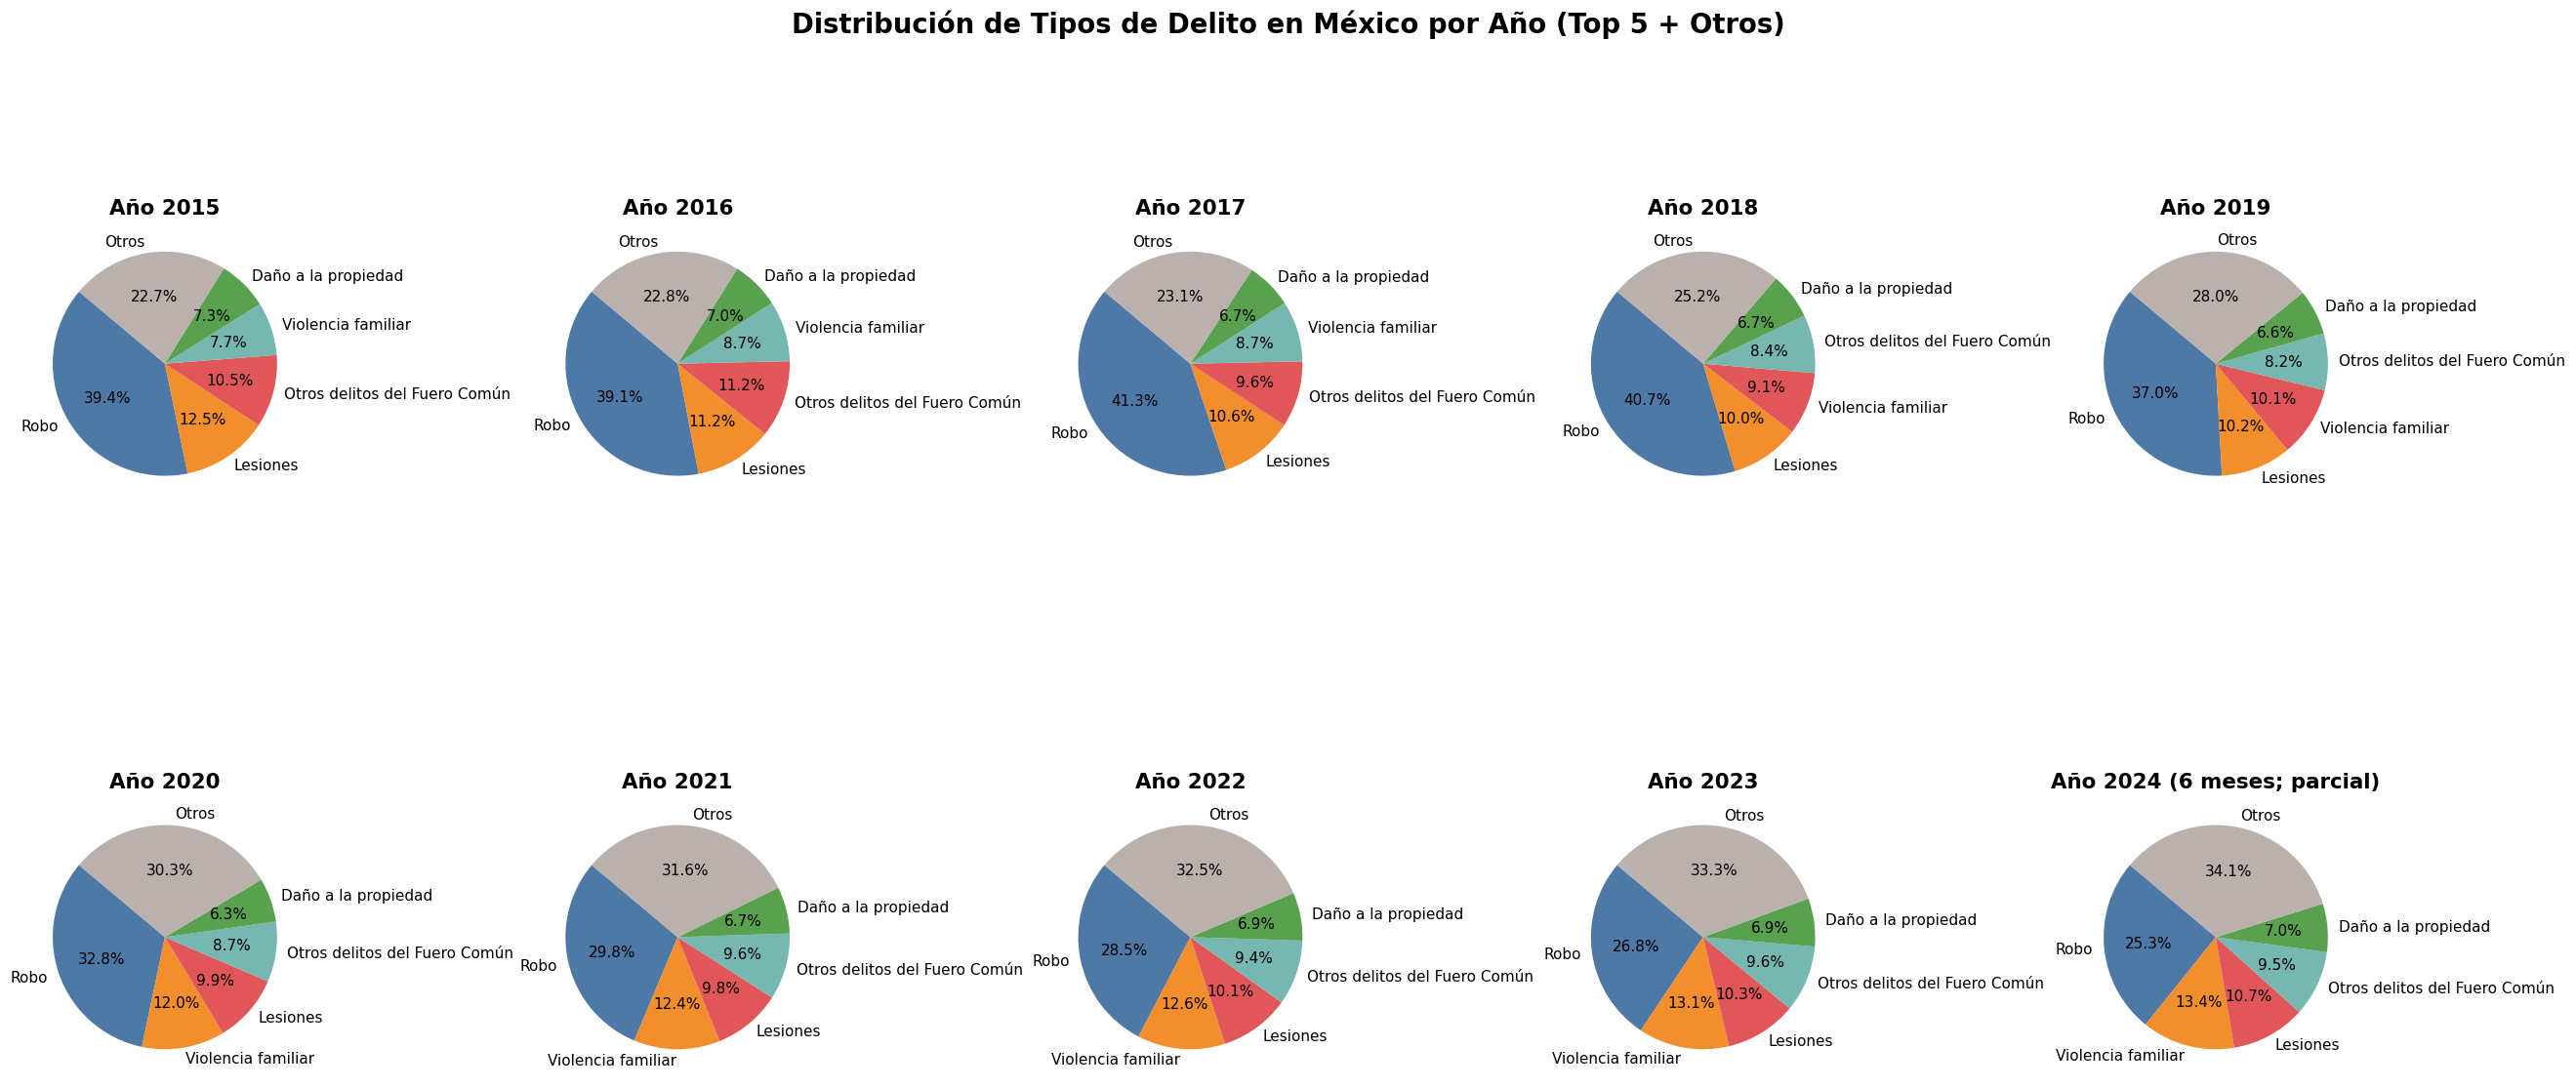

In [5]:
# Ejercicio 3: Gráfica de pastel de tipos de delito para cada año
# Agrupamos los delitos principales (Top 5) y catalogamos el resto como 'Otros' para que sea legible.
years = sorted(df['anio'].unique())

# Configurar cuadrícula de subplots
fig, axes = plt.subplots(int(np.ceil(len(years) / 5)), 5, figsize=(24, 12), squeeze=False)
axes = axes.flatten()

colores = ['#4e79a7', '#f28e2b', '#e15759', '#76b7b2', '#59a14f', '#bab0ac']

for i, yr in enumerate(years):
    df_yr = df[df['anio'] == yr]
    crimes_summary = df_yr.groupby('tipo_de_delito')['frecuencia'].sum().reset_index()
    crimes_summary = crimes_summary.sort_values(by='frecuencia', ascending=False)
    
    # Tomamos Top 5 y agrupamos el resto en 'Otros'
    top5 = crimes_summary.head(5)
    others_val = crimes_summary.iloc[5:]['frecuencia'].sum()
    others_df = pd.DataFrame([{'tipo_de_delito': 'Otros', 'frecuencia': others_val}])
    
    plot_data = pd.concat([top5, others_df], ignore_index=True)
    
    # Graficar pastel en el respectivo subplot
    axes[i].pie(
        plot_data['frecuencia'], 
        labels=plot_data['tipo_de_delito'], 
        autopct='%1.1f%%', 
        startangle=140, 
        colors=colores,
        textprops={'fontsize': 10}
    )
    cobertura = int(meses_reportados.loc[yr])
    etiqueta = f'Año {yr}' if cobertura == 12 else f'Año {yr} ({cobertura} meses; parcial)'
    axes[i].set_title(etiqueta, fontsize=14, fontweight='bold')

for ax in axes[len(years):]:
    ax.set_visible(False)

plt.suptitle('Distribución de Tipos de Delito en México por Año (Top 5 + Otros)', fontsize=18, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

---
#### Calcula la tasa por 100,000 habitantes
##### Tasa por 100,000 habitantes
Mostrar el total de delitos en una entidad no nos sirve de mucho. Es mucho más útil calcular la tasa de incidencia delictiva por cada 100,000 habitantes

$$
tasa = \frac{delitos\space totales}{población} \times 100,000
$$

Esta tasa la podemos anualizar multiplicándola por un factor de 12
$$
tasa\space anualizada = tasa \times 12
$$

Población por entidad federativa según [la encuesta intercensal 2015](https://www.inegi.org.mx/programas/intercensal/2015/)

No tienes que descargar nada. Ya están los datos en la carpeta data

**Interpretación:** multiplicar una tasa mensual por 12 es una anualización, no el total anual observado. Para la tasa anual observada se suman las frecuencias del año y se divide por la población, sin multiplicar otra vez por 12. Se usa población fija de 2015, por lo que las tasas de otros años son aproximaciones con esa referencia. La gráfica final usa todos los homicidios y lo indica en su título.

In [6]:
pobs = pd.read_csv('data/poblacion_entidades_2015.csv', encoding='iso-8859-1', sep=";")
pobs = pobs[['Cve_Entidad', 'Entidad', 'Poblacion']]
pobs = pobs.rename(columns={'Cve_Entidad':'clave_entidad', 'Entidad':'entidad', 'Poblacion':'poblacion'})
pobs.head()

,clave_entidad,entidad,poblacion
0,1,Aguascalientes,1312544.0
1,2,Baja California,3315766.0
2,3,Baja California Sur,712029.0
3,4,Campeche,899931.0
4,5,Coahuila de Zaragoza,5217908.0


In [7]:
# 1. Unir el DataFrame de delitos con el de población
# df tiene 'clave_ent' y pobs tiene 'clave_entidad'
df_tasas = df.merge(pobs, left_on='clave_ent', right_on='clave_entidad', validate='many_to_one')

# Limpiamos columnas redundantes o con sufijos y renombramos para claridad
df_tasas = df_tasas.drop(columns=['clave_entidad', 'entidad_y']).rename(columns={'entidad_x': 'entidad'})

# 2. Calcular la tasa por cada 100,000 habitantes
df_tasas['tasa'] = (df_tasas['frecuencia'] / df_tasas['poblacion']) * 100000

# 3. Anualizar la tasa (multiplicar por 12)
df_tasas['tasa_anualizada'] = df_tasas['tasa'] * 12

print("DataFrame de tasas calculadas:")
display(df_tasas.head())

DataFrame de tasas calculadas:


,anio,clave_ent,entidad,tipo_de_delito,nombre_mes,fecha,frecuencia,poblacion,tasa,tasa_anualizada
0,2015,1,Aguascalientes,Aborto,abril,2015-04-01,0.0,1312544.0,0.000000,0.000000
1,2015,1,Aguascalientes,Aborto,agosto,2015-08-01,0.0,1312544.0,0.000000,0.000000
2,2015,1,Aguascalientes,Aborto,diciembre,2015-12-01,0.0,1312544.0,0.000000,0.000000
3,2015,1,Aguascalientes,Aborto,enero,2015-01-01,0.0,1312544.0,0.000000,0.000000
4,2015,1,Aguascalientes,Aborto,febrero,2015-02-01,3.0,1312544.0,0.228564,2.742765


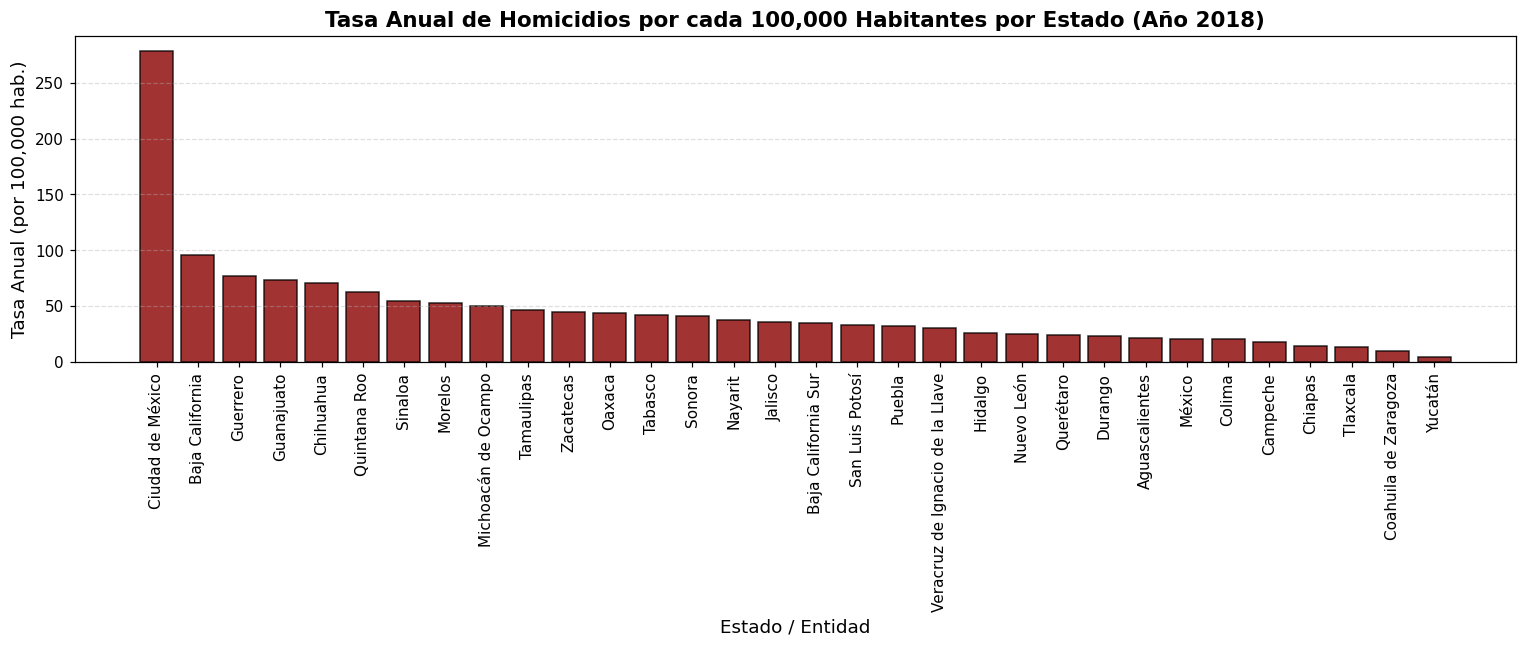

Top 5 de estados con mayor tasa anual de Homicidios en 2018:


,anio,entidad,poblacion,frecuencia,tasa_anual
102,2018,Ciudad de México,711235.0,1979.0,278.248399
97,2018,Baja California,3315766.0,3169.0,95.573692
107,2018,Guerrero,3533251.0,2716.0,76.869716
106,2018,Guanajuato,5853677.0,4298.0,73.423935
101,2018,Chihuahua,2954915.0,2089.0,70.695773


In [8]:
# Vamos a analizar y graficar la tasa anualizada de Homicidios por cada 100,000 habitantes
# agrupando por año y entidad para ver los estados con mayor tasa de homicidios en un año específico (por ejemplo, 2018).
homicidios_tasas = df_tasas[df_tasas['tipo_de_delito'] == 'Homicidio']

# Agrupamos por año, entidad y población para obtener la frecuencia acumulada anual
homicidios_anual = homicidios_tasas.groupby(['anio', 'entidad', 'poblacion'])['frecuencia'].sum().reset_index()

# Calculamos la tasa anual acumulada: (homicidios_totales_anio / poblacion) * 100,000
homicidios_anual['tasa_anual'] = (homicidios_anual['frecuencia'] / homicidios_anual['poblacion']) * 100000

# Ordenar los estados por tasa en el año 2018 de mayor a menor
homicidios_2018 = homicidios_anual[homicidios_anual['anio'] == 2018].sort_values(by='tasa_anual', ascending=False)

# Graficar
plt.figure(figsize=(14, 6))
plt.bar(homicidios_2018['entidad'], homicidios_2018['tasa_anual'], color='darkred', edgecolor='black', alpha=0.8)
plt.title('Tasa Anual de Homicidios por cada 100,000 Habitantes por Estado (Año 2018)', fontsize=14, fontweight='bold')
plt.xlabel('Estado / Entidad', fontsize=12)
plt.ylabel('Tasa Anual (por 100,000 hab.)', fontsize=12)
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# Imprimir el Top 5 de estados con mayor tasa en 2018
print("Top 5 de estados con mayor tasa anual de Homicidios en 2018:")
display(homicidios_2018.head(5))
